## Monocle3 Python

In [1]:
import os
import h5py
import numpy as np
import pandas as pd
import scanpy as sc
from scipy import sparse
from matplotlib import pyplot as plt
from py_monocle import (
    learn_graph,
    order_cells,
    compute_cell_states,
    regression_analysis,
    differential_expression_genes,
)

In [2]:
ROOT_DIR = os.path.abspath("")

In [6]:
DATA_PATH = os.path.join(ROOT_DIR, "scanpy_UMAP_n_neighbors13_npcs34_mindist1.0_spread0.5_cytotrace2.h5ad")

In [4]:
DATA_PATH

'/storage2/liuxiaodongLab/jiangjing/Projects/YutingFu/PD_YutingFu/20250804_h9_changelow_re_monocle3/scanpy_UMAP_n_neighbors13_npcs34_mindist1.0_spread0.5.h5ad'

In [7]:
adata = sc.read_h5ad("scanpy_UMAP_n_neighbors13_npcs34_mindist1.0_spread0.5_cytotrace2.h5ad")

In [8]:
adata.obs["human_celltypes_revised"] = (
    adata.obs["human_celltypes_revised"]
    .astype("category")  # 转换为分类类型
)

In [9]:
with h5py.File(DATA_PATH, "w") as f:
  # Write expression matrix
  exp_matrix = f.create_group("expression_matrix")
  exp_matrix.create_dataset("barcodes", data=adata.obs_names.to_numpy())
  exp_matrix.create_dataset("features", data=adata.var_names.to_numpy())
  exp_matrix.create_dataset("data", data=adata.X.data)
  exp_matrix.create_dataset("indices", data=adata.X.indices)
  exp_matrix.create_dataset("indptr", data=adata.X.indptr)

  # Write UMAP and Louvain clustering
  f.create_dataset("UMAP", data=adata.obsm["X_umap"])
  category_strings = adata.obs["human_celltypes_revised"].astype(str).to_numpy()
  # 创建可变长度的字符串数据集
  dt = h5py.special_dtype(vlen=str)
  f.create_dataset("Louvain", data=category_strings, dtype=dt)

In [10]:
import scipy.sparse as sparse

# 正确读取CSC组件
with h5py.File(DATA_PATH, "r") as f:
    data = f["expression_matrix/data"][()]
    features = [x.decode("utf-8") for x in f["expression_matrix/features"][()]]
    indices = f["expression_matrix/indices"][()]  # 行索引（细胞位置）
    indptr = f["expression_matrix/indptr"][()]    # 列指针（基因维度）
    
    # 动态验证维度
    n_genes = indptr.shape[0] - 1  # CSC格式的列数=基因数
    n_cells = len(f["expression_matrix/barcodes"])

# 重建CSC矩阵
expression_matrix = sparse.csc_matrix(
    (data, indices, indptr),
    shape=(n_cells, n_genes)  # (细胞数, 基因数)
)

#### Learn the trajectory graph

#### Plot trajectory graph

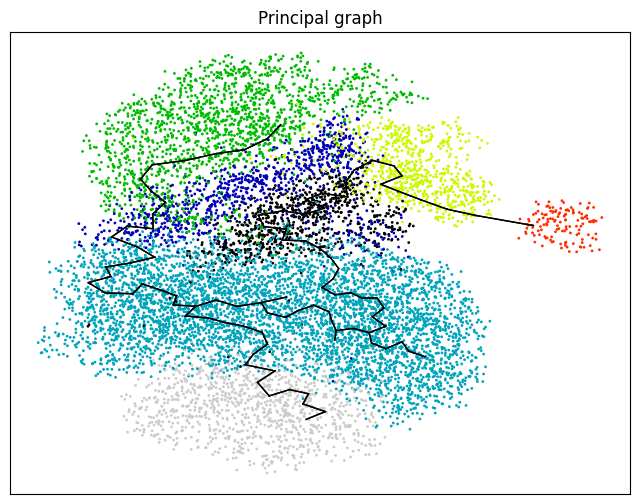

In [18]:
umap = adata.obsm["X_umap"]
unique_categories = adata.obs["human_celltypes_revised"].cat.categories
name_to_code = {name: code for code, name in enumerate(unique_categories)}
louvain = adata.obs["human_celltypes_revised"].map(name_to_code).to_numpy(dtype=int)
projected_points, mst, centroids = learn_graph(matrix=umap, clusters=louvain,k_nn=88,n_centroids=258)
pseudotime = order_cells(
     umap, centroids,
     mst=mst,
     projected_points=projected_points,
     root_cells=2006,
)
plt.figure(1, (8, 6))
plt.title("Principal graph")
plt.scatter(umap[:, 0], umap[:, 1], c=louvain, s=1, cmap="nipy_spectral")
edges = np.array(mst.nonzero()).T
for edge in edges:
     plt.plot(centroids[edge, 0], centroids[edge, 1], c="black", linewidth=1)
plt.xticks([])
plt.yticks([])
plt.show()

In [16]:
# 创建布尔掩码筛选符合条件的细胞
mask = (
    (umap[:, 0] >= -2) & (umap[:, 0] <= 2) &  # UMAP1条件
    (umap[:, 1] >= -5) & (umap[:, 1] <= -1)   # UMAP2条件
)
candidate_indices = np.where(mask)[0]  # 符合条件的细胞索引

print(f"找到 {len(candidate_indices)} 个候选细胞")


找到 744 个候选细胞


In [17]:
candidate_indices

array([   44,   143,  1991,  1997,  2000,  2006,  2008,  2011,  2012,
        2026,  2030,  2039,  2040,  2044,  2052,  2062,  2092,  2106,
        2112,  2132,  2135,  2142,  2144,  2161,  2164,  2180,  2248,
        2257,  2265,  2295,  2302,  2303,  2317,  2341,  2342,  2351,
        2365,  2392,  2395,  2399,  2403,  2411,  2416,  2418,  2424,
        2425,  2436,  2464,  2467,  2485,  2494,  2509,  2520,  2522,
        2525,  2529,  2530,  2534,  2547,  2551,  2560,  2563,  2578,
        2586,  2595,  2596,  2599,  2601,  2605,  2608,  2614,  2623,
        2630,  2634,  2639,  2646,  2648,  2667,  2671,  2673,  2674,
        2679,  2684,  2686,  2701,  2703,  2729,  2730,  2734,  2737,
        2740,  2743,  2775,  2777,  2802,  2811,  2831,  2836,  2845,
        2847,  2857,  2864,  2884,  2902,  2904,  2936,  2941,  2942,
        2946,  2952,  2973,  2998,  2999,  3005,  3006,  3022,  3033,
        3040,  3052,  3063,  3093,  3111,  3114,  3120,  3122,  3123,
        3124,  3163,

In [20]:
from scipy.spatial import KDTree
def find_nearest_principal_nodes(
    matrix: np.ndarray,
    centroids: np.ndarray,
):
  """Find the nearest nodes on the principal graph of matrix.

  Parameters
  ----------
  matrix : ``ndarray``
    The matrix to find the nearest edge, recommended UMAP embeddings.
  centroids : ``ndarray``
    The centroids of the principal graph.

  Returns
  -------
  nearest_nodes: ``list``
    The indices of the nearest nodes.
  """
  kdtree = KDTree(centroids)
  nearest_nodes = kdtree.query(matrix, k=1)[1]
  return nearest_nodes.reshape(-1)

In [21]:
# 假设 root_cells 是用户指定的原始细胞索引
user_root_cells = [2006]  # 示例输入

# 步骤 1: 用户输入的 root_cells → 主图节点 (root_pr_cells)
root_cell_coords = umap[user_root_cells].reshape(-1, 2)
root_pr_cells = find_nearest_principal_nodes(root_cell_coords, centroids)

# 检查主图节点坐标
print("主图节点索引:", root_pr_cells)
print("主图节点坐标:\n", centroids[root_pr_cells])

主图节点索引: [86]
主图节点坐标:
 [[ 0.56528226 -2.1326032 ]]


In [22]:
# 步骤 2: 主图节点 → 原始数据中的最终 root_cells
pr_node_coords = centroids[root_pr_cells].reshape(-1, 2)
final_root_cells = find_nearest_principal_nodes(pr_node_coords, umap)

# 输出最终根细胞的坐标
print("最终根细胞索引:", final_root_cells)
print("最终根细胞坐标:\n", umap[final_root_cells])


最终根细胞索引: [6884]
最终根细胞坐标:
 [[ 0.5694752 -2.1083567]]


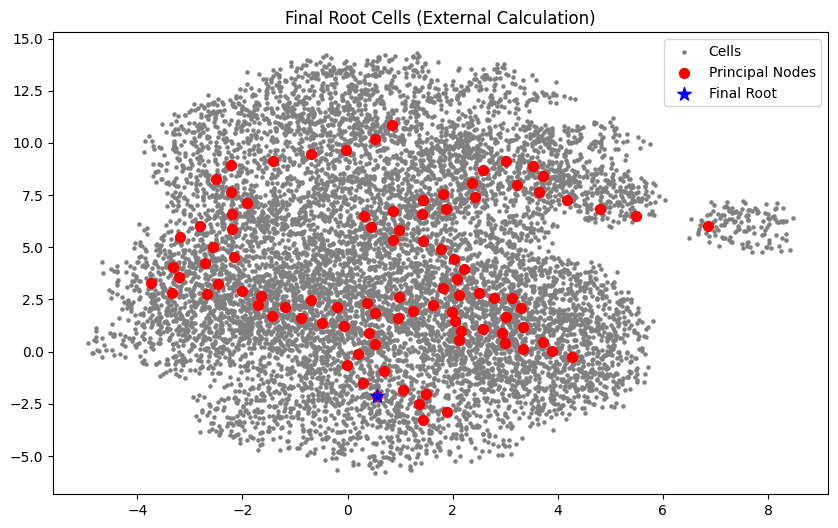

In [23]:
plt.figure(figsize=(10, 6))
plt.scatter(umap[:, 0], umap[:, 1], c='gray', s=5, label="Cells")
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=50, label="Principal Nodes")
plt.scatter(umap[final_root_cells, 0], umap[final_root_cells, 1], 
            c='blue', s=100, marker='*', label="Final Root")
plt.legend()
plt.title("Final Root Cells (External Calculation)")
plt.show()

In [24]:
adata.obs["pseudotime"] = pseudotime 

In [25]:
adata.uns["trajectory_mst"] = mst.toarray()  # 将稀疏矩阵转为密集数组保存
adata.uns["trajectory_centroids"] = centroids

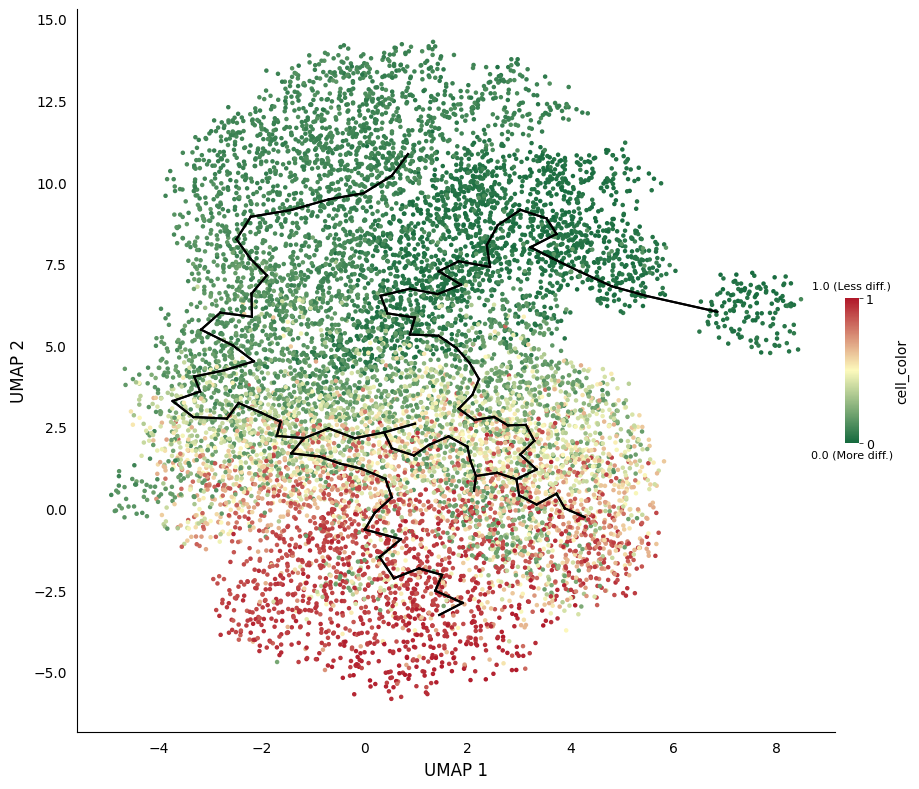

In [27]:
###monocle3+cytotrace2
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

# Define color nodes (RGB values normalized to 0-1)
high_color = np.array([176, 23, 41]) / 255.0 
mid_color = np.array([253, 250, 188]) / 255.0 
low_color = np.array([21, 106, 62]) / 255.0  

# Create custom colormap (reversed from original)
colors = [low_color,mid_color, high_color]
custom_cmap = LinearSegmentedColormap.from_list("custom_cytotrace", colors)

# Create figure
plt.figure(1, (10, 8))

# ---- Step 1: Plot UMAP points (colored by CytoTRACE2 score) ----
sc = plt.scatter(
    umap[:, 0], 
    umap[:, 1], 
    c=adata.obs['CytoTRACE2_Relative'],  # CytoTRACE2 score
    cmap=custom_cmap,  
    s=5,              # Point size
    alpha=1,        # Transparency
    zorder=1          # Bottom layer
)

# ---- Step 2: Plot Monocle3 trajectory (MST) ----
edges = np.array(mst.nonzero()).T
for edge in edges:
    plt.plot(
        centroids[edge, 0], 
        centroids[edge, 1], 
        c='black', 
        linewidth=1.5, 
        zorder=3  # Trajectory on top
    )

# ---- Adjust axis style ----
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel("UMAP 1", fontsize=12)
ax.set_ylabel("UMAP 2", fontsize=12)
ax.tick_params(axis='both', which='both', bottom=False, left=False)

# ---- Adjust colorbar (shorter height) ----
cbar = plt.colorbar(sc, pad=0.01, aspect=10,shrink=0.2)  # Reduced aspect ratio makes it shorter
cbar.set_ticks([0, 1])  # 只显示0和1两个刻度
cbar.ax.tick_params(
    labelsize=9,
    width=0.5,
    length=3,  # 缩短刻度线长度
    pad=2      # 调整刻度标签与颜色条的间距
) 
cbar.outline.set_visible(False)  # 移除颜色条边框黑线
cbar.set_label("cell_color", fontsize=10, labelpad=5)

# Add colorbar labels closer to the bar
cbar.ax.text(0.5, -0.05, "0.0 (More diff.)",  # Moved labels closer
            transform=cbar.ax.transAxes,
            ha='center', va='top', fontsize=8)
cbar.ax.text(0.5, 1.05, "1.0 (Less diff.)", 
            transform=cbar.ax.transAxes,
            ha='center', va='bottom', fontsize=8)

# Adjust colorbar label position
cbar.ax.yaxis.set_label_coords(3.5, 0.5)  # Moves label to the right

# ---- Final adjustments ----
plt.tight_layout()
plt.savefig("Final_Plot.png", dpi=300, bbox_inches="tight")
plt.show()

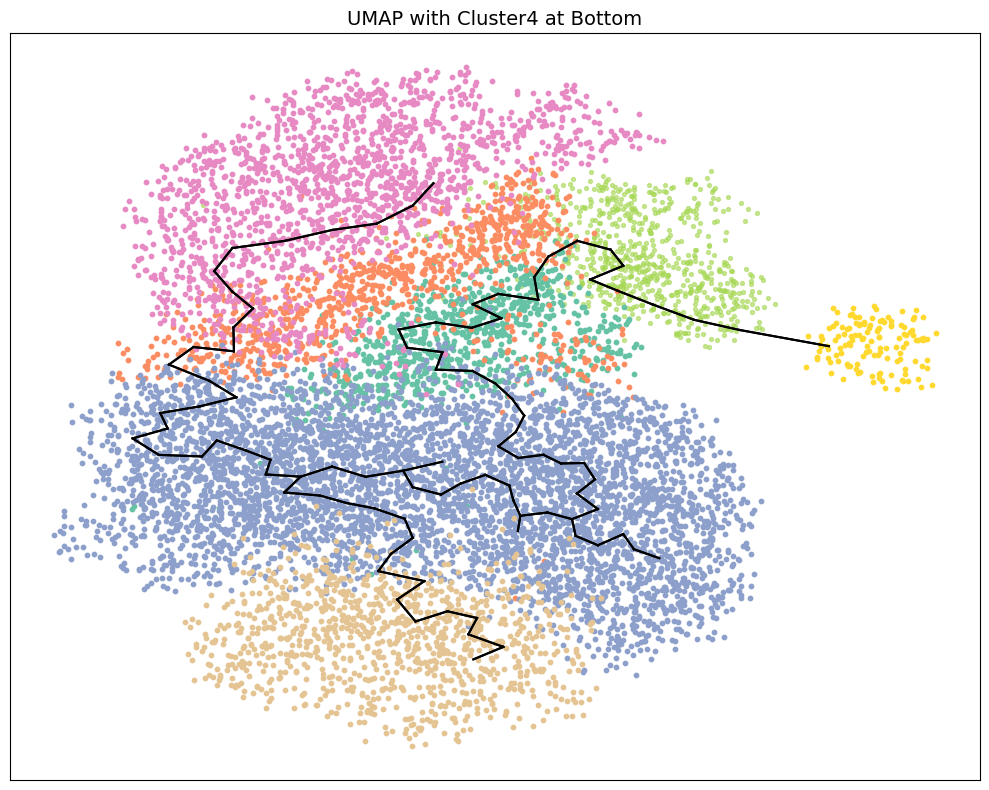

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap

# 假设 cluster4 的整数编码为 4（需确认实际情况）
target_cluster = 4

# 获取所有聚类标签（排除 cluster4）
all_clusters = np.unique(louvain)
other_clusters = all_clusters[all_clusters != target_cluster]

# 定义颜色映射（为每个聚类分配独特颜色）
n_clusters = len(all_clusters)

# 使用scanpy默认的Set2色系（自动扩展超过8个颜色时会循环）
set2_colors = plt.get_cmap("Set2").colors
color_list = [set2_colors[i % len(set2_colors)] for i in range(n_clusters)]

# 创建颜色字典（确保顺序与scanpy一致）
cluster_colors = {cluster: color_list[i] for i, cluster in enumerate(all_clusters)}
plt.figure(figsize=(10, 8))
plt.title(f"UMAP with Cluster{target_cluster} at Bottom", fontsize=14)

# ---- Step 1: 先绘制 cluster4（最底层）----
mask_target = (louvain == target_cluster)
plt.scatter(
    umap[mask_target, 0], umap[mask_target, 1],
    c=[cluster_colors[target_cluster]],  # 使用预定义颜色
    s=8,
    alpha=0.6,  # 根据需要调整透明度
    label=f"Cluster {target_cluster}",
    zorder=1  # 最低图层
)

# ---- Step 2: 依次绘制其他聚类（覆盖在上层）----
for cluster in other_clusters:
    mask = (louvain == cluster)
    plt.scatter(
        umap[mask, 0], umap[mask, 1],
        c=[cluster_colors[cluster]],
        s=10,
        alpha=1,
        label=f"Cluster {cluster}",
        zorder=2  # 更高图层
    )

# ---- Step 3: 绘制轨迹图的边（最上层）----
edges = np.array(mst.nonzero()).T
for edge in edges:
    plt.plot(
        centroids[edge, 0], 
        centroids[edge, 1], 
        c="black", 
        linewidth=1.5, 
        zorder=3  # 确保边在最上方
    )

plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.savefig(f'umap_custom_layer_cluster{target_cluster}.pdf', dpi=300, bbox_inches='tight')
plt.show()


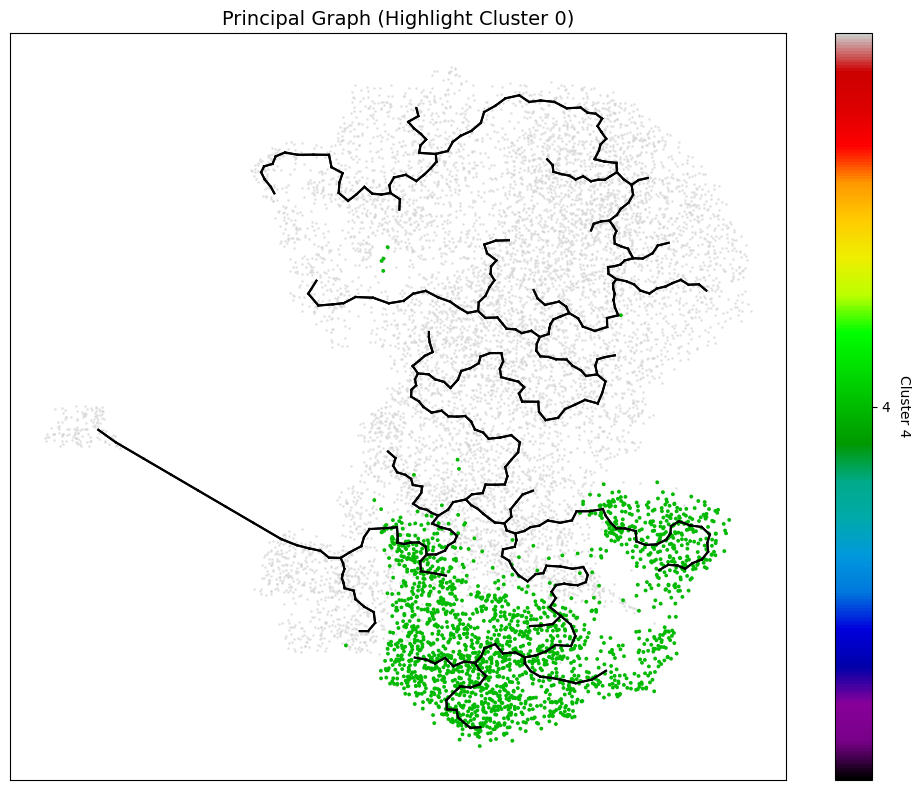

In [94]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(1, (10, 8))
plt.title("Principal Graph (Highlight Cluster 0)", fontsize=14)

# 定义目标聚类（例如高亮聚类0）
target_cluster = 4

# ---- 步骤1：绘制所有细胞为灰色背景 ----
plt.scatter(
    umap[:, 0], umap[:, 1],
    c="lightgray",  # 设置其他细胞颜色为灰色
    s=1,            # 点的大小
    alpha=0.5       # 透明度
)

# ---- 步骤2：高亮目标聚类的细胞 ----
# 创建布尔掩码筛选目标聚类的细胞
mask = (louvain == target_cluster)

# 绘制目标聚类的细胞（使用颜色映射）
highlight = plt.scatter(
    umap[mask, 0], umap[mask, 1],
    c=louvain[mask],   # 使用原始聚类颜色
    cmap="nipy_spectral", 
    s=3,               # 可调整高亮点的大小
    alpha=1            # 不透明
)

# ---- 步骤3：绘制轨迹图的边 ----
edges = np.array(mst.nonzero()).T
for edge in edges:
    plt.plot(
        centroids[edge, 0], 
        centroids[edge, 1], 
        c="black", 
        linewidth=1.5, 
        zorder=2  # 确保边在点的上方
    )

# ---- 可选：添加颜色条和高亮标签 ----
# 添加颜色条（仅显示目标聚类的颜色）
cbar = plt.colorbar(highlight, ticks=[target_cluster])
cbar.set_label(f"Cluster {target_cluster}", rotation=270, labelpad=15)

plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.savefig('monocle3_highlight_cluster.png', dpi=300, bbox_inches='tight')
plt.show()

In [14]:
import itertools
import matplotlib.pyplot as plt

# 定义参数搜索空间
param_grid = {
    'k_nn': list(range(80, 101,2)),       # 测试不同邻域大小
    'n_centroids':list(range(100, 300,2))
}

# 生成所有参数组合
all_params = itertools.product(param_grid['n_centroids'], param_grid['k_nn'])

# 循环测试每个参数组合
for idx, (nc_value,knn_value) in enumerate(all_params):
    # 训练主图模型
    projected_points, mst, centroids = learn_graph(
        matrix=umap,
        clusters=louvain,
        n_centroids=nc_value,
        k_nn=knn_value,
        kmeans_seed=0
    )
    
    # 计算伪时间
    pseudotime = order_cells(
        umap, centroids,
        mst=mst,
        projected_points=projected_points,
        root_cells=0,
    )
    
    # 创建带参数标注的可视化
    plt.figure(figsize=(8, 6), dpi=300)
    plt.title(f"n_centroids={nc_value}, k_nn={knn_value}")
    plt.scatter(umap[:, 0], umap[:, 1], c=louvain, s=1, cmap="nipy_spectral")
    
    # 绘制主图边
    edges = np.array(mst.nonzero()).T
    for edge in edges:
        plt.plot(centroids[edge, 0], centroids[edge, 1], c="black", linewidth=1)
    
    # 修饰图形
    plt.axis('off')
    
    # 保存并关闭图形（避免内存泄漏）
    plt.savefig(f"./monocle3_figure/trajectory_centroids{nc_value}_k_nn{knn_value}.png", 
                bbox_inches='tight', transparent=True)
    plt.close()

print("所有参数组合测试完成！")

所有参数组合测试完成！


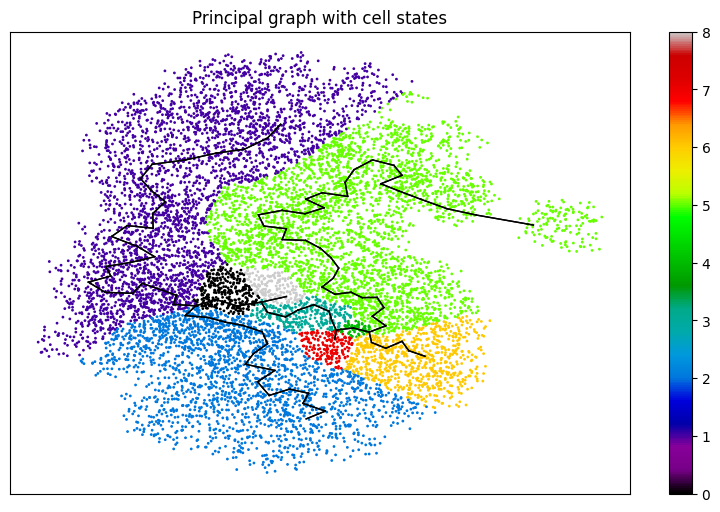

In [30]:
plt.figure(1, (10, 6))
plt.title("Principal graph with cell states")
cell_states, _ = compute_cell_states(umap, centroids, mst)
plt.scatter(umap[:, 0], umap[:, 1], c=cell_states, s=1, cmap="nipy_spectral")
plt.colorbar()
edges = np.array(mst.nonzero()).T
for edge in edges:
    plt.plot(centroids[edge, 0], centroids[edge, 1], c="black", linewidth=1)
plt.xticks([])
plt.yticks([])
plt.show()

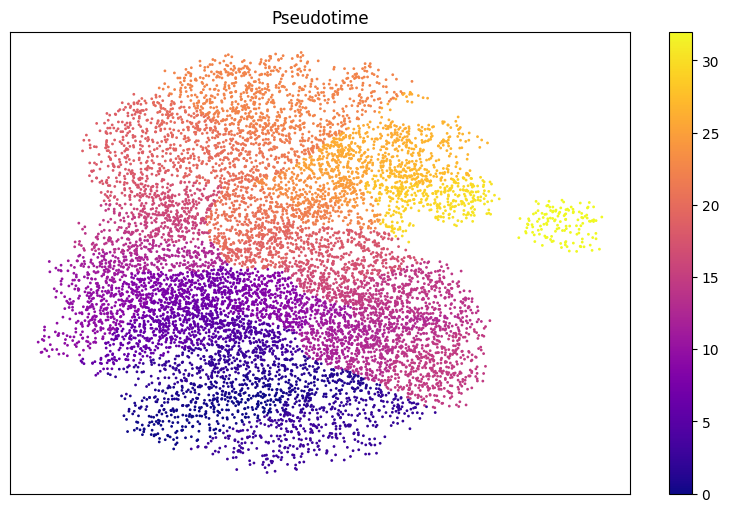

In [31]:
plt.figure(1, (10, 6))
plt.title("Pseudotime")
plt.scatter(umap[:, 0], umap[:, 1], c=pseudotime, s=1, cmap="plasma")
plt.xticks([])
plt.yticks([])
plt.colorbar()
plt.show()

#### Differential Expression Genes

In [32]:
morans_i_scores, pvalues, adjusted_pvalues = differential_expression_genes(
    expression_matrix,
    projected_cells=projected_points,
)
morani_results = pd.DataFrame(
    {
        "Moran's I score": morans_i_scores,
        "P-values": np.round(pvalues, 4),
        "Adjusted P-values": np.round(adjusted_pvalues, 4),
        "Gene Indices": np.arange(len(morans_i_scores))
    },
    index=pd.Series(features, name="Genes"),
).sort_values("Moran's I score", ascending=False)
morani_results.head(100)

/home/liuxiaodongLab/jiangjing/miniconda3/envs/diffusionmap/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)
/home/liuxiaodongLab/jiangjing/.local/lib/python3.9/site-packages/scanpy/metrics/_common.py:62: UserWarning: 1030 variables were constant, will return nan for these.
  warnings.warn(


,Moran's I score,P-values,Adjusted P-values,Gene Indices
Genes,,,,
CSMD1,0.813193,0.0,NaN,10011
SPTBN4,0.749482,0.0,NaN,21054
KLHL1,0.731094,0.0,NaN,15732
PCDH15,0.730417,0.0,NaN,12079
KCNJ6,0.730364,0.0,NaN,22508
...,...,...,...,...
STMN1,0.559936,0.0,NaN,405
NACA,0.558796,0.0,NaN,14796
RPL15,0.558271,0.0,NaN,4234


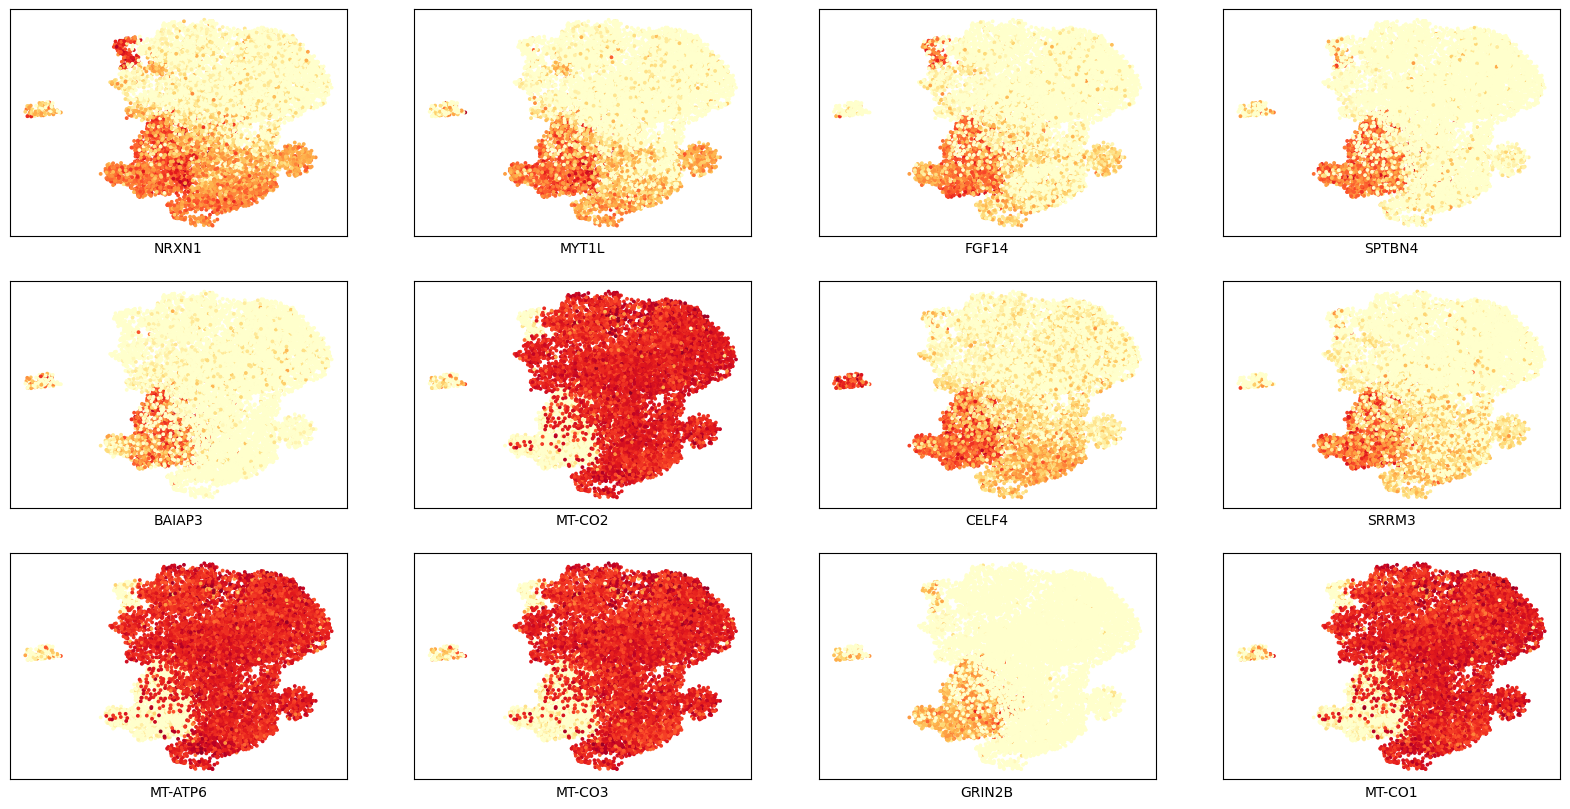

In [42]:
plt.figure(12, (20, 10))
for i, gene_idx in enumerate(morani_results["Gene Indices"].values[:12]):
    plt.subplot(3, 4, i + 1)
    plt.scatter(umap[:, 0], umap[:, 1], c=expression_matrix[:, gene_idx].toarray(), s=3, cmap="YlOrRd")
    plt.xticks([])
    plt.yticks([])
    plt.xlabel(features[gene_idx])
plt.show()

In [33]:
# 1. 筛选差异表达基因
significant_genes = morani_results[(morani_results['P-values'] == 0) & 
                                  (morani_results["Moran's I score"] > 0.25)].index.tolist()

# 2. 定义两个轨迹的细胞类型顺序
trajectory1 = ['Rgl1-like', 'DA progenitor-FABP7', 'DA progenitor-CHRNB3 high', 'Immature DA', 'Mature DA']

# 3. 获取每个轨迹对应的细胞索引并按轨迹顺序排序
def get_trajectory_cells(adata, trajectory_order):
    # 获取轨迹中所有细胞类型的细胞
    traj_cells = adata.obs[adata.obs['human_celltypes_revised'].isin(trajectory_order)].copy()
    
    # 为每个细胞分配轨迹顺序权重
    def get_order(x):
        try:
            return trajectory_order.index(x)
        except ValueError:
            return np.nan
    
    traj_cells['traj_order'] = traj_cells['human_celltypes_revised'].apply(get_order)
    traj_cells = traj_cells.dropna(subset=['traj_order'])
    
    # 获取这些细胞在原始adata.obs中的整数位置索引
    cell_indices = adata.obs.index.get_indexer(traj_cells.index)
    
    # 直接从pseudotime数组中获取对应的伪时间值
    traj_cells['pseudotime'] = pseudotime[cell_indices]
    
    # 按轨迹顺序和伪时间排序
    traj_cells_sorted = traj_cells.sort_values(['traj_order', 'pseudotime'])
    
    # 返回排序后的细胞索引和它们在原始矩阵中的位置
    return traj_cells_sorted.index, adata.obs.index.get_indexer(traj_cells_sorted.index)

# 获取轨迹细胞（返回名称索引和位置索引）
traj1_cell_indices, traj1_cell_positions = get_trajectory_cells(adata, trajectory1)


In [34]:

# 4. 提取表达矩阵子集
# 获取基因在特征列表中的索引
gene_indices = [features.index(gene) for gene in significant_genes if gene in features]

# 转换为稠密矩阵以便切片（注意：如果数据很大可能需要其他处理方式）
if sparse.issparse(expression_matrix):
    expression_matrix = expression_matrix.toarray()

# 获取轨迹1的表达数据
traj1_expr = expression_matrix[traj1_cell_positions][:, gene_indices]

# 5. 绘制热图
import seaborn as sns

# 1. 对每个基因计算沿轨迹的表达趋势
def calculate_gene_trends(expr_data):
    """计算每个基因沿轨迹的表达趋势（斜率）"""
    # 创建伪时间点（0到1标准化）
    x = np.linspace(0, 1, expr_data.shape[0])
    trends = []
    
    for i in range(expr_data.shape[1]):
        # 对每个基因的表达值进行标准化
        y = expr_data[:, i]
        y = (y - y.min()) / (y.max() - y.min() + 1e-6)
        
        # 计算线性回归斜率（趋势强度）
        slope = np.polyfit(x, y, 1)[0]
        trends.append(slope)
    
    return np.array(trends)

# 计算两个轨迹的趋势
traj1_trends = calculate_gene_trends(traj1_expr)

# 2. 根据趋势对基因排序（从高到低）
traj1_sorted_indices = np.argsort(traj1_trends)[::1]  

# 3. 按排序后的基因重新排列表达矩阵
traj1_expr_sorted = traj1_expr[:, traj1_sorted_indices]

# 获取排序后的基因名称
sorted_genes_traj1 = [significant_genes[i] for i in traj1_sorted_indices]



In [35]:
import numpy as np
from scipy.interpolate import make_smoothing_spline

# 假设 traj1_expr_sorted 是已经排序后的表达矩阵 (cells x genes)
# 第一个平滑步骤：类似 smooth.spline(x, df=3)
def smooth_along_trajectory(expr_matrix, df=3):
    """
    沿轨迹方向（列）平滑表达矩阵
    参数:
        expr_matrix: 表达矩阵 (cells × genes)
        df: 自由度
    返回:
        平滑后的矩阵 (cells × genes)
    """
    n_cells = expr_matrix.shape[0]
    x = np.linspace(0, 1, n_cells)  # 伪时间坐标
    
    smoothed = np.zeros_like(expr_matrix)
    for gene_idx in range(expr_matrix.shape[1]):  # 对每个基因
        y = expr_matrix[:, gene_idx]
        spline = make_smoothing_spline(x, y, lam=df)
        smoothed[:, gene_idx] = spline(x)
    
    return smoothed


def minmax_normalize_matrix(expr_matrix):
    """
    对表达矩阵的每一列（基因）进行Min-Max归一化到[0,1]
    参数:
        expr_matrix: numpy数组
    返回:
        归一化后的矩阵
    """
    # 按列（基因）计算最小值和范围
    min_vals = np.min(expr_matrix, axis=0, keepdims=True)
    max_vals = np.max(expr_matrix, axis=0, keepdims=True)
    range_vals = max_vals - min_vals

    # 避免除零错误（若某基因在所有cell中表达相同）
    range_vals[range_vals == 0] = 1

    return (expr_matrix - min_vals) / range_vals

smoothed_traj1 = smooth_along_trajectory(traj1_expr_sorted, df=3)

# 使用新的归一化函数
processed_traj1 = minmax_normalize_matrix(smoothed_traj1)



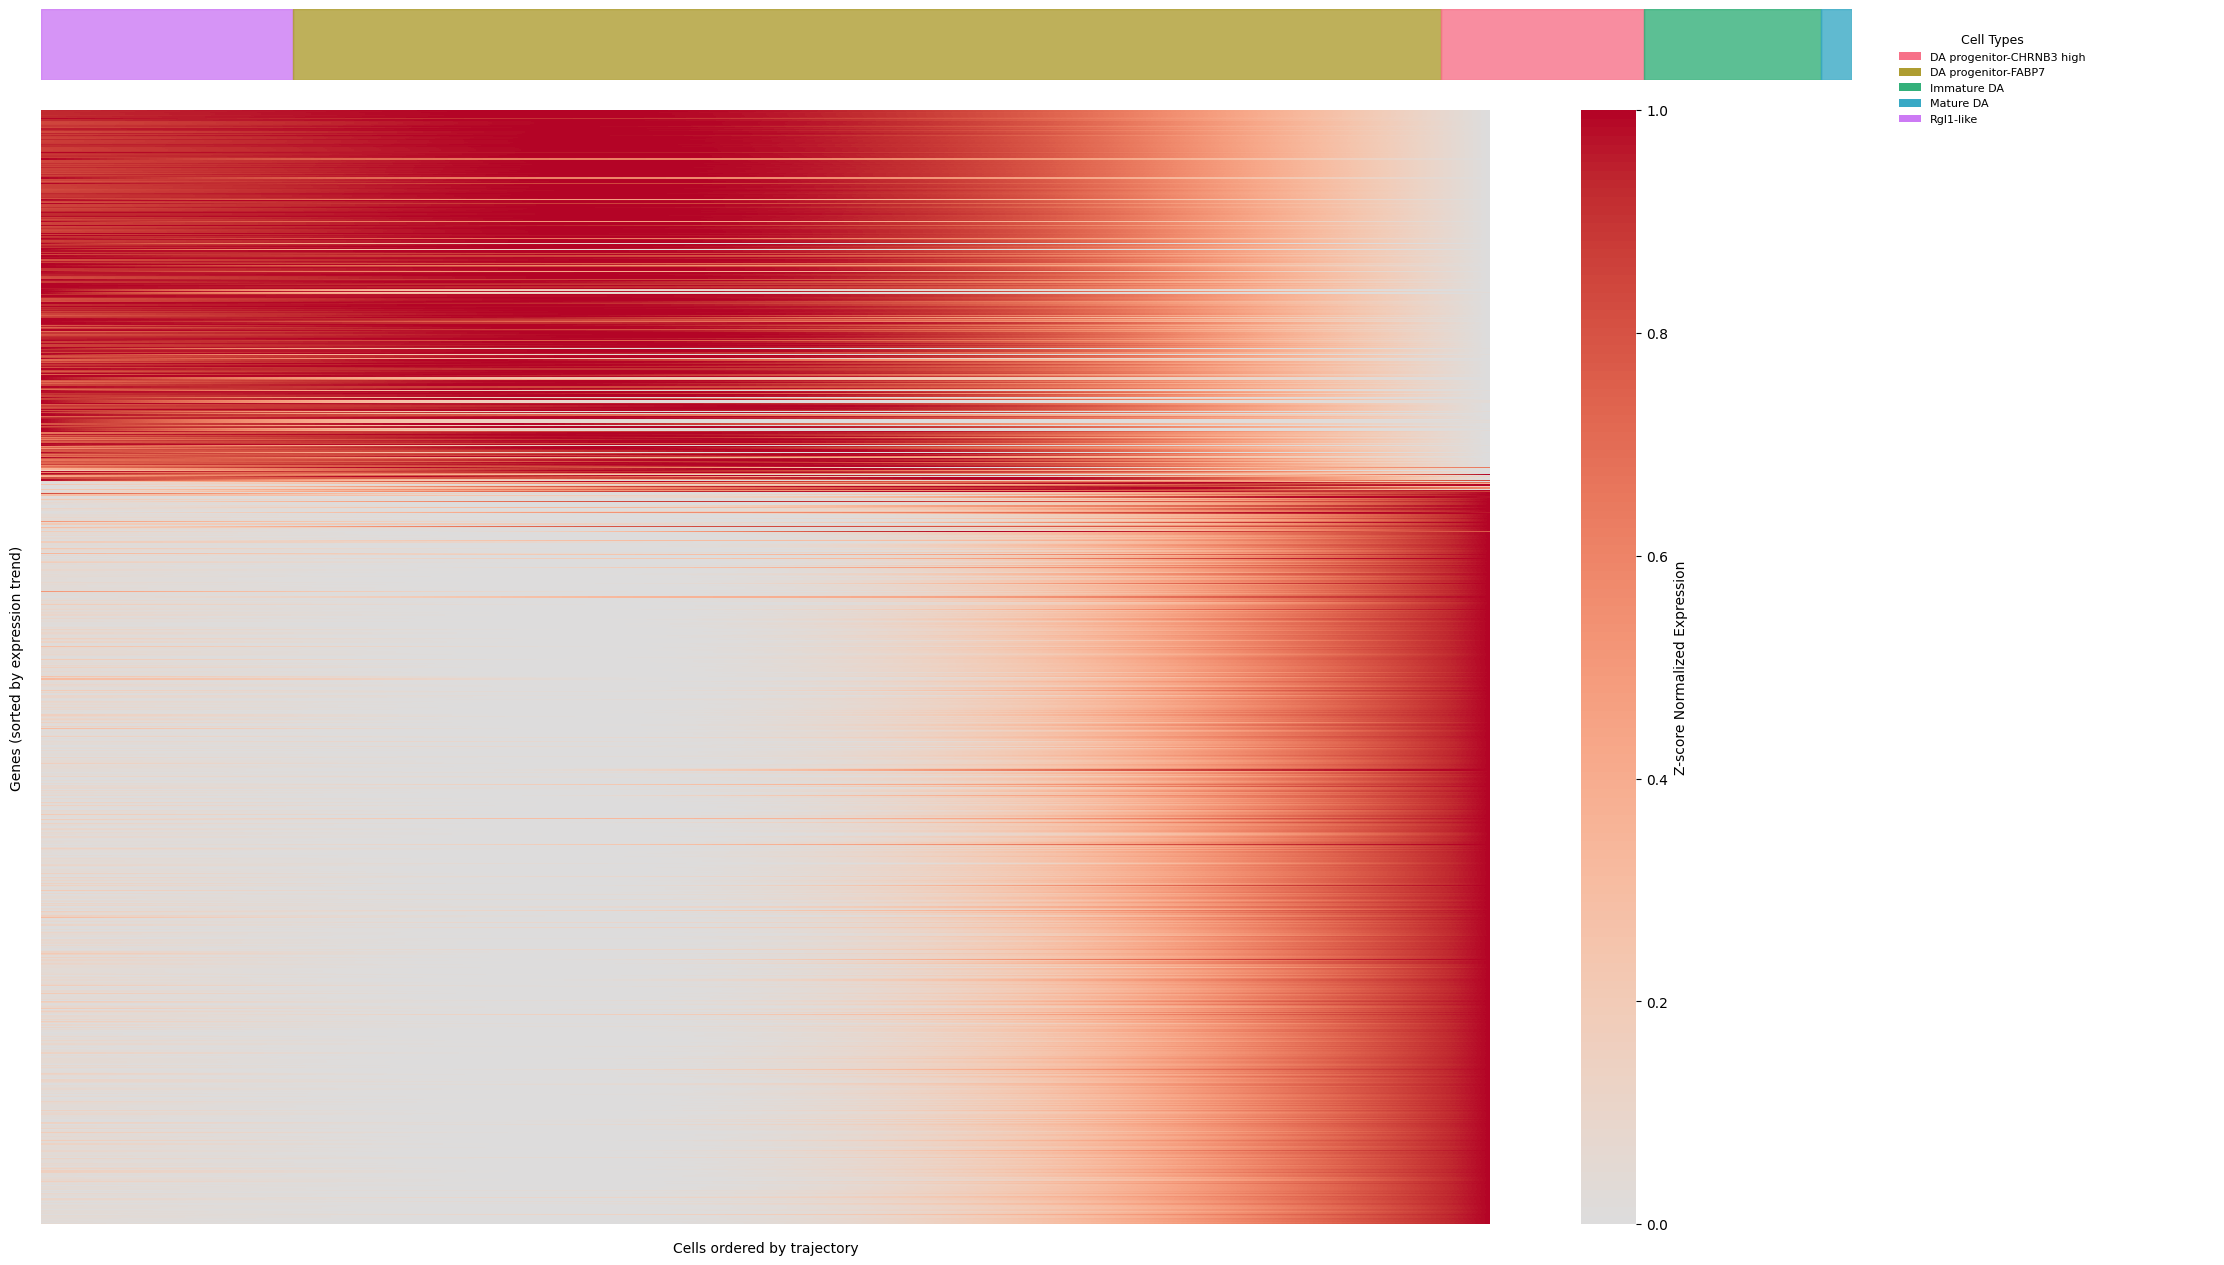

NameError: name 'processed_traj2' is not defined

In [36]:
from matplotlib.patches import Patch  # 添加这行导入
from matplotlib import pyplot as plt
import seaborn as sns
def plot_processed_heatmap(expr_data, cell_labels, gene_names, title, filename=None):
    """
    参数:
        expr_data: 表达矩阵 (cells x genes)
        cell_labels: 细胞标签
        gene_names: 基因名称列表
        title: 图标题
        filename: 保存文件名(可选)
    """
    # 配置参数
    COLORBAR_HEIGHT_RATIO = 0.06  # 颜色条高度占比
    LEGEND_SPACE = 0.15           # 右侧图例预留空间比例
    
    n_genes = len(gene_names)
    n_cells = len(cell_labels)
    
    # 动态计算画布尺寸（核心修改）
    base_width = n_cells * 0.01
    fig_width = min(20, max(10, base_width)) / (1 - LEGEND_SPACE)  # 补偿图例空间
    fig_height = min(15, max(6, n_genes * 0.15 + 1))  # 总高度包含颜色条
    
    # 创建画布和网格系统（关键修改）
    fig = plt.figure(figsize=(fig_width, fig_height))
    gs = fig.add_gridspec(
        nrows=2, 
        ncols=1,
        height_ratios=[COLORBAR_HEIGHT_RATIO, 1 - COLORBAR_HEIGHT_RATIO],
        hspace=0.05,
        left=0.08,
        right=1 - LEGEND_SPACE  # 为图例保留统一空间
    )
    
    # 获取细胞类型分段信息
    cell_types = adata.obs.loc[cell_labels, 'human_celltypes_revised'].values
    type_segments = []
    last_type = None
    for i, ct in enumerate(cell_types):
        if ct != last_type:
            if last_type is not None:
                type_segments.append((start_idx, i, last_type))
            start_idx = i
            last_type = ct
    type_segments.append((start_idx, n_cells, last_type))
    
    # 创建颜色映射
    unique_types = sorted({seg[2] for seg in type_segments})
    palette = sns.color_palette("husl", len(unique_types))
    color_map = dict(zip(unique_types, palette))
    
    # ==================== 颜色条绘制 ====================
    ax_color = fig.add_subplot(gs[0])
    
    # 绘制精确对齐的颜色块（关键修改）
    for start, end, ct in type_segments:
        ax_color.axvspan(
            start - 0.5,  # 左边界对齐热图单元格
            end - 0.5,    # 右边界对齐热图单元格
            color=color_map[ct],
            alpha=0.8
        )
    
    # 设置颜色条坐标轴
    ax_color.set_xlim(-0.5, n_cells - 0.5)  # 精确匹配热图坐标
    ax_color.set_ylim(0, 1)
    ax_color.axis('off')
    
    # ==================== 主热图绘制 ====================
    ax_heat = fig.add_subplot(gs[1], sharex=ax_color)  # 严格共享x轴
    
    sns.heatmap(
        expr_data.T,
        cmap='coolwarm',
        center=0,
        yticklabels=False,
        xticklabels=False,
        cbar_kws={'label': 'Z-score Normalized Expression'},
        ax=ax_heat
    )
    
    # 坐标轴标签
    ax_heat.set_xlabel('Cells ordered by trajectory', labelpad=12, fontsize=10)
    ax_heat.set_ylabel('Genes (sorted by expression trend)', labelpad=12, fontsize=10)
    
    # ==================== 动态图例系统 ====================
    # 在颜色条右侧创建图例（关键修改）
    legend_ax = ax_color.inset_axes(
        [1.02, 0.2, 0.18, 0.6],  # 相对于颜色条ax的位置
        transform=ax_color.transAxes
    )
    
    # 创建图例元素
    legend_elements = [
        Patch(facecolor=color_map[ct], label=ct) 
        for ct in unique_types
    ]
    
    legend_ax.legend(
        handles=legend_elements,
        loc='upper left',
        frameon=False,
        fontsize=8,
        title='Cell Types',
        title_fontsize=9
    )
    legend_ax.axis('off')
    
    # ==================== 布局调整 ====================
    plt.subplots_adjust(
        top=0.95 - COLORBAR_HEIGHT_RATIO,
        bottom=0.08
    )
    
    if filename:
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        plt.close()
    else:
        plt.show()

# 正确调用方式 - 使用关键字参数
plot_processed_heatmap(
    expr_data=processed_traj1,
    cell_labels=traj1_cell_indices,
    gene_names=sorted_genes_traj1,
    title='Processed Gene Expression along Trajectory 1',
   # filename='trajectory1_heatmap.png'
)

plot_processed_heatmap(
    expr_data=processed_traj2,
    cell_labels=traj2_cell_indices,
    gene_names=sorted_genes_traj2,
    title='Processed Gene Expression along Trajectory 2',
    #filename='trajectory2_heatmap_unsuitable.png'
)

In [38]:
# 1. 筛选差异表达基因
significant_genes = morani_results[(morani_results['P-values'] == 0) & 
                                  (morani_results["Moran's I score"] > 0.25)].index.tolist()

# 2. 定义两个轨迹的细胞类型顺序
trajectory2 = ['Rgl1-like','DA progenitor-FABP7', 'DA progenitor-CHRNB3 low', 'DA progenitor-terminal']

# 3. 获取每个轨迹对应的细胞索引并按轨迹顺序排序
def get_trajectory_cells(adata, trajectory_order):
    # 获取轨迹中所有细胞类型的细胞
    traj_cells = adata.obs[adata.obs['human_celltypes_revised'].isin(trajectory_order)].copy()
    
    # 为每个细胞分配轨迹顺序权重
    def get_order(x):
        try:
            return trajectory_order.index(x)
        except ValueError:
            return np.nan
    
    traj_cells['traj_order'] = traj_cells['human_celltypes_revised'].apply(get_order)
    traj_cells = traj_cells.dropna(subset=['traj_order'])
    
    # 获取这些细胞在原始adata.obs中的整数位置索引
    cell_indices = adata.obs.index.get_indexer(traj_cells.index)
    
    # 直接从pseudotime数组中获取对应的伪时间值
    traj_cells['pseudotime'] = pseudotime[cell_indices]
    
    # 按轨迹顺序和伪时间排序
    traj_cells_sorted = traj_cells.sort_values(['traj_order', 'pseudotime'])
    
    # 返回排序后的细胞索引和它们在原始矩阵中的位置
    return traj_cells_sorted.index, adata.obs.index.get_indexer(traj_cells_sorted.index)

traj2_cell_indices, traj2_cell_positions = get_trajectory_cells(adata, trajectory2)

In [39]:

# 4. 提取表达矩阵子集
# 获取基因在特征列表中的索引
gene_indices = [features.index(gene) for gene in significant_genes if gene in features]

# 转换为稠密矩阵以便切片（注意：如果数据很大可能需要其他处理方式）
if sparse.issparse(expression_matrix):
    expression_matrix = expression_matrix.toarray()

traj2_expr = expression_matrix[traj2_cell_positions][:, gene_indices]

# 5. 绘制热图
import seaborn as sns

# 1. 对每个基因计算沿轨迹的表达趋势
def calculate_gene_trends(expr_data):
    """计算每个基因沿轨迹的表达趋势（斜率）"""
    # 创建伪时间点（0到1标准化）
    x = np.linspace(0, 1, expr_data.shape[0])
    trends = []
    
    for i in range(expr_data.shape[1]):
        # 对每个基因的表达值进行标准化
        y = expr_data[:, i]
        y = (y - y.min()) / (y.max() - y.min() + 1e-6)
        
        # 计算线性回归斜率（趋势强度）
        slope = np.polyfit(x, y, 1)[0]
        trends.append(slope)
    
    return np.array(trends)

traj2_trends = calculate_gene_trends(traj2_expr)

traj2_sorted_indices = np.argsort(traj2_trends)[::1]

traj2_expr_sorted = traj2_expr[:, traj2_sorted_indices]

sorted_genes_traj2 = [significant_genes[i] for i in traj2_sorted_indices]



In [40]:
import numpy as np
from scipy.interpolate import make_smoothing_spline

# 假设 traj1_expr_sorted 是已经排序后的表达矩阵 (cells x genes)
# 第一个平滑步骤：类似 smooth.spline(x, df=3)
def smooth_along_trajectory(expr_matrix, df=3):
    """
    沿轨迹方向（列）平滑表达矩阵
    参数:
        expr_matrix: 表达矩阵 (cells × genes)
        df: 自由度
    返回:
        平滑后的矩阵 (cells × genes)
    """
    n_cells = expr_matrix.shape[0]
    x = np.linspace(0, 1, n_cells)  # 伪时间坐标
    
    smoothed = np.zeros_like(expr_matrix)
    for gene_idx in range(expr_matrix.shape[1]):  # 对每个基因
        y = expr_matrix[:, gene_idx]
        spline = make_smoothing_spline(x, y, lam=df)
        smoothed[:, gene_idx] = spline(x)
    
    return smoothed


# 第二个标准化步骤：Z-score标准化 (x-mean(x))/sd(x)
def zscore_standardize_matrix(expr_matrix):
    """
    对表达矩阵的每一行(基因)进行Z-score标准化
    参数:
        expr_matrix: numpy数组
    返回:
        标准化后的矩阵
    """
    # 按行标准化 (每个基因)
    row_means = np.mean(expr_matrix, axis=0, keepdims=True)
    row_stds = np.std(expr_matrix, axis=0, keepdims=True)
    return (expr_matrix - row_means) / (row_stds + 1e-6)  # 加小值防止除零

smoothed_traj2 = smooth_along_trajectory(traj2_expr_sorted, df=3)

processed_traj2 = zscore_standardize_matrix(smoothed_traj2)



In [41]:
import numpy as np
from scipy.interpolate import make_smoothing_spline

# 假设 traj1_expr_sorted 是已经排序后的表达矩阵 (cells x genes)
# 第一个平滑步骤：类似 smooth.spline(x, df=3)
def smooth_along_trajectory(expr_matrix, df=3):
    """
    沿轨迹方向（列）平滑表达矩阵
    参数:
        expr_matrix: 表达矩阵 (cells × genes)
        df: 自由度
    返回:
        平滑后的矩阵 (cells × genes)
    """
    n_cells = expr_matrix.shape[0]
    x = np.linspace(0, 1, n_cells)  # 伪时间坐标
    
    smoothed = np.zeros_like(expr_matrix)
    for gene_idx in range(expr_matrix.shape[1]):  # 对每个基因
        y = expr_matrix[:, gene_idx]
        spline = make_smoothing_spline(x, y, lam=df)
        smoothed[:, gene_idx] = spline(x)
    
    return smoothed


def minmax_normalize_matrix(expr_matrix):
    """
    对表达矩阵的每一列（基因）进行Min-Max归一化到[0,1]
    参数:
        expr_matrix: numpy数组
    返回:
        归一化后的矩阵
    """
    # 按列（基因）计算最小值和范围
    min_vals = np.min(expr_matrix, axis=0, keepdims=True)
    max_vals = np.max(expr_matrix, axis=0, keepdims=True)
    range_vals = max_vals - min_vals

    # 避免除零错误（若某基因在所有cell中表达相同）
    range_vals[range_vals == 0] = 1

    return (expr_matrix - min_vals) / range_vals

smoothed_traj2 = smooth_along_trajectory(traj2_expr_sorted, df=3)

# 使用新的归一化函数
processed_traj2 = minmax_normalize_matrix(smoothed_traj2)


In [47]:
from matplotlib.patches import Patch
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np

def plot_processed_heatmap(expr_data, cell_labels, gene_names, title, filename=None, export_data=False):
    """
    参数:
        expr_data: 表达矩阵 (cells x genes)
        cell_labels: 细胞标签（必须与expr_data行顺序一致）
        gene_names: 基因名称列表
        title: 图标题
        filename: 保存文件名(可选)
        export_data: 是否导出细胞类型对应的表达数据(布尔值)
    """
    custom_colors = [
       "#F2BB6B",
       "#276C9E",  
       "#F2BB6B",
       "#862a2d"   
    ]

    # 创建分段线性插值色带
    cmap_uniform = LinearSegmentedColormap.from_list("custom_uniform", custom_colors, N=256)
    # 配置参数
    COLORBAR_HEIGHT_RATIO = 0.06  # 颜色条高度占比
    LEGEND_WIDTH_RATIO = 0.15     # 图例宽度比例
    
    n_genes = len(gene_names)
    n_cells = len(cell_labels)

    # 动态计算画布尺寸
    base_width = n_cells * 0.15
    fig_width = min(20, max(10, base_width)) / (1 - LEGEND_WIDTH_RATIO)
    fig_height = min(15, max(6, n_genes * 0.15 + 1))
    
    # 创建画布和网格系统
    fig = plt.figure(figsize=(fig_width, fig_height))
    gs = fig.add_gridspec(
        nrows=2, 
        ncols=2,
        height_ratios=[COLORBAR_HEIGHT_RATIO, 1 - COLORBAR_HEIGHT_RATIO],
        width_ratios=[1, LEGEND_WIDTH_RATIO],
        hspace=0.05,
        wspace=0.05,
        left=0.08,
        right=0.92
    )
    
    # 获取细胞类型分段信息
    cell_types = adata.obs.loc[cell_labels, 'human_celltypes_revised'].values
    type_segments = []
    last_type = None

    # 反转细胞类型顺序
    reversed_cell_types = cell_types[::-1]
    reversed_expr_data = expr_data[::-1, :]
    
    for i, ct in enumerate(reversed_cell_types ):
        if ct != last_type:
            if last_type is not None:
                type_segments.append((start_idx, i, last_type))
            start_idx = i
            last_type = ct
    type_segments.append((start_idx, n_cells, last_type))

    # ==================== 数据导出功能 ====================
    if export_data:
        import pandas as pd
        
        # 创建字典保存每个细胞类型的表达数据
        celltype_expr_dict = {}
        
        for start, end, ct in type_segments:
            # 获取该细胞类型对应的表达数据
            ct_expr = expr_data[start:end, :]
            
            # 创建DataFrame (cells x genes)
            df = pd.DataFrame(
                ct_expr,
                index=cell_labels[start:end],
                columns=gene_names
            )
            
            # 添加细胞类型列
            df['celltype'] = ct
            
            # 保存到字典
            celltype_expr_dict[ct] = df
        
        # 合并所有细胞类型的数据
        combined_df = pd.concat(celltype_expr_dict.values())
        
        # 导出为CSV文件
        output_filename = title.replace(" ", "_") + "_expression_data.csv"
        combined_df.to_csv(output_filename, index=True)
        print(f"表达数据已导出到: {output_filename}")

    
    # 创建颜色映射
    unique_types = sorted({seg[2] for seg in type_segments})
    palette = sns.color_palette("husl", len(unique_types))
    color_map = dict(zip(unique_types, palette))
    
    # ==================== 颜色条绘制 ====================
    ax_color = fig.add_subplot(gs[0, 0])
    
    # 绘制精确对齐的颜色块（使用热图坐标系）
    for start, end, ct in type_segments:
        ax_color.axvspan(
            start - 0.5,  # 热图单元格左边界
            end - 0.5,    # 热图单元格右边界
            color=color_map[ct],
            alpha=0.8
        )
    
    # 设置与热图完全一致的坐标轴
    ax_color.set_xlim(-0.5, n_cells - 0.5)
    ax_color.set_ylim(0, 1)
    ax_color.axis('off')
    
    # ==================== 主热图绘制 ====================
    ax_heat = fig.add_subplot(gs[1, 0], sharex=ax_color)
    
    # 转置数据为（genes x cells）
    heatmap_data = reversed_expr_data.T
    
    # 绘制热图（禁用自动坐标调整）
    sns.heatmap(
        heatmap_data,
        cmap=cmap_uniform,
        center=0,
        yticklabels=False,
        xticklabels=False,
        cbar_kws={'label': 'Normalized Expression'}
    )
    # 获取颜色条对象并调整字体
    cbar = ax_heat.collections[0].colorbar
    cbar.set_label(cbar.ax.yaxis.get_label().get_text(), 
              size=20, 
              labelpad=15)
    cbar.ax.tick_params(labelsize=20)
    
    # 强制设置坐标轴范围
    ax_heat.set_xlim(-0.5, n_cells - 0.5)
    ax_heat.set_ylim(n_genes + 0.5, -0.5)  # 修正y轴方向
    
    # 添加调试网格线（可选）
    for seg in type_segments:
        ax_heat.axvline(seg[0]-0.5, color='black', linewidth=0.5, linestyle='--')
        ax_heat.axvline(seg[1]-0.5, color='black', linewidth=0.5, linestyle='--')
    
    # ==================== 图例系统 ====================
    legend_ax = fig.add_subplot(gs[:, 1])
    
    # 创建图例元素
    legend_elements = [
        Patch(facecolor=color_map[ct], label=ct) 
        for ct in unique_types
    ]
    
    legend = legend_ax.legend(
        handles=legend_elements,
        loc='center',
        bbox_to_anchor=(0.5, 0.5 + COLORBAR_HEIGHT_RATIO/2),
        frameon=False,
        fontsize=20,
        title='Cell Types',
        title_fontsize=21
    )
    legend._legend_box.align = "left"
    legend_ax.axis('off')
    
    # ==================== 最终布局调整 ====================
    plt.subplots_adjust(
        top=0.95 - COLORBAR_HEIGHT_RATIO,
        bottom=0.08
    )
    
    # 添加标题
    fig.suptitle(title, y=0.98, fontsize=12)
    
    if filename:
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        plt.close()
    else:
        plt.show()

plot_processed_heatmap(
    expr_data=processed_traj2,
    cell_labels=traj2_cell_indices,
    gene_names=sorted_genes_traj2,
    title='Processed Gene Expression along Trajectory 2',
    filename='trajectory2_heatmap_suitable.pdf',
    export_data=False  # 启用数据导出
)


In [46]:
from matplotlib.patches import Patch
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np

def plot_processed_heatmap(expr_data, cell_labels, gene_names, title, filename=None, export_data=False):
    """
    参数:
        expr_data: 表达矩阵 (cells x genes)
        cell_labels: 细胞标签（必须与expr_data行顺序一致）
        gene_names: 基因名称列表
        title: 图标题
        filename: 保存文件名(可选)
        export_data: 是否导出细胞类型对应的表达数据(布尔值)
    """
    
    custom_colors = [
       "#F2BB6B",
       "#276C9E",  
       "#F2BB6B",
       "#862a2d"   
    ]

    # 创建分段线性插值色带
    cmap_uniform = LinearSegmentedColormap.from_list("custom_uniform", custom_colors, N=256)
    # 配置参数
    COLORBAR_HEIGHT_RATIO = 0.06  # 颜色条高度占比
    LEGEND_WIDTH_RATIO = 0.15     # 图例宽度比例
    
    n_genes = len(gene_names)
    n_cells = len(cell_labels)
    
    # 验证数据一致性
    if expr_data.shape[0] != n_cells:
        raise ValueError("expr_data行数必须与cell_labels长度一致")

    # 动态计算画布尺寸
    base_width = n_cells * 0.01
    fig_width = min(20, max(10, base_width)) / (1 - LEGEND_WIDTH_RATIO)
    fig_height = min(15, max(6, n_genes * 0.15 + 1))
    
    # 创建画布和网格系统
    fig = plt.figure(figsize=(fig_width, fig_height))
    gs = fig.add_gridspec(
        nrows=2, 
        ncols=2,
        height_ratios=[COLORBAR_HEIGHT_RATIO, 1 - COLORBAR_HEIGHT_RATIO],
        width_ratios=[1, LEGEND_WIDTH_RATIO],
        hspace=0.05,
        wspace=0.05,
        left=0.08,
        right=0.92
    )
    
    # 获取细胞类型分段信息
    cell_types = adata.obs.loc[cell_labels, 'human_celltypes_revised'].values
    type_segments = []
    last_type = None
    
    for i, ct in enumerate(cell_types ):
        if ct != last_type:
            if last_type is not None:
                type_segments.append((start_idx, i, last_type))
            start_idx = i
            last_type = ct
    type_segments.append((start_idx, n_cells, last_type))

    # ==================== 数据导出功能 ====================
    if export_data:
        import pandas as pd
        
        # 创建字典保存每个细胞类型的表达数据
        celltype_expr_dict = {}
        
        for start, end, ct in type_segments:
            # 获取该细胞类型对应的表达数据
            ct_expr = expr_data[start:end, :]
            
            # 创建DataFrame (cells x genes)
            df = pd.DataFrame(
                ct_expr,
                index=cell_labels[start:end],
                columns=gene_names
            )
            
            # 添加细胞类型列
            df['celltype'] = ct
            
            # 保存到字典
            celltype_expr_dict[ct] = df
        
        # 合并所有细胞类型的数据
        combined_df = pd.concat(celltype_expr_dict.values())
        
        # 导出为CSV文件
        output_filename = title.replace(" ", "_") + "_expression_data.csv"
        combined_df.to_csv(output_filename, index=True)
        print(f"表达数据已导出到: {output_filename}")
        
    # 创建颜色映射
    unique_types = sorted({seg[2] for seg in type_segments})
    palette = sns.color_palette("husl", len(unique_types))
    color_map = dict(zip(unique_types, palette))
    
    # ==================== 颜色条绘制 ====================
    ax_color = fig.add_subplot(gs[0, 0])
    
    # 绘制精确对齐的颜色块（使用热图坐标系）
    for start, end, ct in type_segments:
        ax_color.axvspan(
            start - 0.5,  # 热图单元格左边界
            end - 0.5,    # 热图单元格右边界
            color=color_map[ct],
            alpha=0.8
        )
    
    # 设置与热图完全一致的坐标轴
    ax_color.set_xlim(-0.5, n_cells - 0.5)
    ax_color.set_ylim(0, 1)
    ax_color.axis('off')
    
    # ==================== 主热图绘制 ====================
    ax_heat = fig.add_subplot(gs[1, 0], sharex=ax_color)
    
    # 转置数据为（genes x cells）
    heatmap_data = expr_data.T
    
    # 绘制热图（禁用自动坐标调整）
    sns.heatmap(
        heatmap_data,
        cmap=cmap_uniform,
        center=0,
        yticklabels=False,
        xticklabels=False,
        cbar_kws={'label': 'Normalized Expression'},
        ax=ax_heat
    )

    # 获取颜色条对象并调整字体
    cbar = ax_heat.collections[0].colorbar
    cbar.set_label(cbar.ax.yaxis.get_label().get_text(), 
              size=20, 
              labelpad=15)
    cbar.ax.tick_params(labelsize=20)
    # 强制设置坐标轴范围
    ax_heat.set_xlim(-0.5, n_cells - 0.5)
    ax_heat.set_ylim(n_genes + 0.5, -0.5)  # 修正y轴方向
    
    # 添加调试网格线（可选）
    for seg in type_segments:
        ax_heat.axvline(seg[0]-0.5, color='black', linewidth=0.5, linestyle='--')
        ax_heat.axvline(seg[1]-0.5, color='black', linewidth=0.5, linestyle='--')
    
    # ==================== 图例系统 ====================
    legend_ax = fig.add_subplot(gs[:, 1])
    
    # 创建图例元素
    legend_elements = [
        Patch(facecolor=color_map[ct], label=ct) 
        for ct in unique_types
    ]
    
    legend = legend_ax.legend(
        handles=legend_elements,
        loc='center',
        bbox_to_anchor=(0.5, 0.5 + COLORBAR_HEIGHT_RATIO/2),
        frameon=False,
        fontsize=20,
        title='Cell Types',
        title_fontsize=21
    )
    legend._legend_box.align = "left"
    legend_ax.axis('off')
    
    # ==================== 最终布局调整 ====================
    plt.subplots_adjust(
        top=0.95 - COLORBAR_HEIGHT_RATIO,
        bottom=0.08
    )
    
    # 添加标题
    fig.suptitle(title, y=0.98, fontsize=12)
    
    if filename:
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        plt.close()
    else:
        plt.show()

plot_processed_heatmap(
    expr_data=processed_traj1,
    cell_labels=traj1_cell_indices,
    gene_names=sorted_genes_traj1,
    title='Processed Gene Expression along Trajectory 1',
    filename='trajectory1_heatmap.pdf',
    export_data=False  # 启用数据导出
)

In [44]:
import pandas as pd
import numpy as np

def get_genes_top_celltypes(expr_data, cell_labels, gene_names, adata):
    """
    计算每个基因在哪个细胞类型中平均表达量最高
    
    参数:
        expr_data: 表达矩阵 (cells x genes)
        cell_labels: 细胞ID列表（与expr_data行顺序一致）
        gene_names: 基因名称列表
        adata: AnnData对象，包含细胞类型信息
    
    返回:
        DataFrame 包含两列: [gene, top_celltype]
    """
    # 获取细胞类型信息
    cell_types = adata.obs.loc[cell_labels, 'human_celltypes_revised'].values
    
    # 创建DataFrame存储表达数据
    df_expr = pd.DataFrame(expr_data, columns=gene_names)
    df_expr['celltype'] = cell_types
    
    # 计算每个基因在各细胞类型的平均表达量
    mean_expr = df_expr.groupby('celltype').mean()
    
    # 找出每个基因表达量最高的细胞类型
    result = pd.DataFrame({
        'gene': gene_names,
        'top_celltype': mean_expr.idxmax(axis=0).values,
        'max_expression': mean_expr.max(axis=0).values
    })
    
    return result.sort_values('max_expression', ascending=False).reset_index(drop=True)

# 使用示例
gene_celltype_df = get_genes_top_celltypes(
    expr_data=processed_traj1,
    cell_labels=traj1_cell_indices,
    gene_names=sorted_genes_traj1,
    adata=adata
)

# 打印前20个结果
print("基因及其最高表达的细胞类型:")
print(gene_celltype_df.head(20))

# 导出为CSV
gene_celltype_df.to_csv('gene_top_celltypes_traj1.csv', index=False)

基因及其最高表达的细胞类型:
        gene top_celltype  max_expression
0      PTPRK    Rgl1-like        0.999811
1     MT-ND6    Rgl1-like        0.999613
2   CACNA2D1    Mature DA        0.999393
3       MID1    Rgl1-like        0.999090
4     ZNF521    Rgl1-like        0.998281
5      CDH18    Mature DA        0.998107
6      CPNE4    Mature DA        0.997983
7      GRIK2    Mature DA        0.997732
8       SGCZ    Mature DA        0.997728
9      NHLH1    Mature DA        0.997141
10      NFIA    Rgl1-like        0.997022
11     NHSL1    Rgl1-like        0.996495
12       MIF    Rgl1-like        0.996209
13     RPL35    Rgl1-like        0.996039
14      NWD2  Immature DA        0.995939
15       FN1    Rgl1-like        0.995897
16     OPCML    Mature DA        0.995397
17    KANSL1    Rgl1-like        0.994790
18      RYR2    Mature DA        0.994050
19     PPDPF    Rgl1-like        0.994042


/tmp/ipykernel_434878/3615684751.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_expr = df_expr.groupby('celltype').mean()


In [48]:
from matplotlib.patches import Patch
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import LinearSegmentedColormap  # 添加缺失的导入

def plot_processed_heatmap(expr_data, cell_labels, gene_names, title, filename=None, export_data=False):
    """
    参数:
        expr_data: 表达矩阵 (cells x genes)
        cell_labels: 细胞标签（必须与expr_data行顺序一致）
        gene_names: 基因名称列表
        title: 图标题
        filename: 保存文件名(可选)
        export_data: 是否导出细胞类型对应的表达数据(布尔值)
    """
    custom_colors = [
       "#F2BB6B",
       "#276C9E",  
       "#F2BB6B",
       "#862a2d"   
    ]
    # 创建分段线性插值色带
    cmap_uniform = LinearSegmentedColormap.from_list("custom_uniform", custom_colors, N=256)
    # 动态计算画布尺寸
    GENE_HEIGHT = 0.3  # 每个基因占用的高度（单位：英寸）
    LEGEND_WIDTH_RATIO = 0.15
    
    n_genes = len(gene_names)
    n_cells = len(cell_labels)

    # 调整画布尺寸
    fig_width = 40  # 固定宽度保持细胞类型颜色条的可读性
    fig_height = max(n_genes * GENE_HEIGHT, 6)  # 设置最小高度
    
    # 创建画布和网格系统
    fig = plt.figure(figsize=(fig_width, fig_height))
    gs = fig.add_gridspec(
       nrows=1,  # 改为单行布局
       ncols=2,
       width_ratios=[0.85, 0.15],  # 主图占85%
       left=0.18,  # 减少左侧边距
       right=0.96
    )
    
    # 获取细胞类型分段信息
    cell_types = adata.obs.loc[cell_labels, 'human_celltypes_revised'].values
    type_segments = []
    last_type = None
    
    for i, ct in enumerate(cell_types):
        if ct != last_type:
            if last_type is not None:
                type_segments.append((start_idx, i, last_type))
            start_idx = i
            last_type = ct
    type_segments.append((start_idx, n_cells, last_type))

    # ==================== 数据导出功能 ====================
    if export_data:
        import pandas as pd
        
        # 创建字典保存每个细胞类型的表达数据
        celltype_expr_dict = {}
        
        for start, end, ct in type_segments:
            # 获取该细胞类型对应的表达数据
            ct_expr = expr_data[start:end, :]
            
            # 创建DataFrame (cells x genes)
            df = pd.DataFrame(
                ct_expr,
                index=cell_labels[start:end],
                columns=gene_names
            )
            
            # 添加细胞类型列
            df['celltype'] = ct
            
            # 保存到字典
            celltype_expr_dict[ct] = df
        
        # 合并所有细胞类型的数据
        combined_df = pd.concat(celltype_expr_dict.values())
        
        # 导出为CSV文件
        output_filename = title.replace(" ", "_") + "_expression_data.csv"
        combined_df.to_csv(output_filename, index=True)
        print(f"表达数据已导出到: {output_filename}")

    # ==================== 主热图绘制 ====================
    ax_heat = fig.add_subplot(gs[0, 0])
    
    # 转置数据为（genes x cells）
    heatmap_data = expr_data.T
    
    # 绘制热图（禁用自动坐标调整）
    sns.heatmap(
        heatmap_data,
        cmap=cmap_uniform,
        center=0,
        yticklabels=gene_names,
        xticklabels=False,
        cbar_kws={'label': 'Normalized Expression'},
        square=False,  # 禁用正方形单元格
        linewidths=0   # 关闭单元格分割线
    )

    # 调整基因名显示参数
    ax_heat.tick_params(
        axis='y', 
        labelsize=16,  # 减小字体大小
        rotation=0,   # 水平显示
        pad=2         # 调整标签与热图的间距
    )
    
    
    # 添加调试网格线（可选）
    for seg in type_segments:
        ax_heat.axvline(seg[0]-0.5, color='black', linewidth=0.5, linestyle='--')
        ax_heat.axvline(seg[1]-0.5, color='black', linewidth=0.5, linestyle='--')
    
    # ==================== 最终布局调整 ====================
    plt.subplots_adjust(top=0.9, bottom=0.15)
    fig.suptitle(title, y=0.95, fontsize=18)

    if filename:
        plt.savefig(filename)
        plt.close()
    else:
        plt.show()

plot_processed_heatmap(
    expr_data=processed_traj1,
    cell_labels=traj1_cell_indices,
    gene_names=sorted_genes_traj1,
    title='',
    filename='trajectory1_heatmap_genename.pdf',
    export_data=False  # 启用数据导出
)


#### Regression Analysis

In [72]:
np.random.seed(52)
rand_gene_indices = np.random.permutation(len(features))[:50]
gene_names = np.array(features)[rand_gene_indices]
subset_expression_matrix = expression_matrix.tocsc()[:, rand_gene_indices]

with h5py.File(DATA_PATH, "r") as f:
  R_pseudotime = f["pseudotime"][()]

KeyError: "Unable to synchronously open object (object 'pseudotime' doesn't exist)"

In [11]:
pvals_matrix = regression_analysis(subset_expression_matrix, pseudotime, cell_states)
pvals_matrix_R = regression_analysis(subset_expression_matrix, R_pseudotime, cell_states)

In [ ]:
n_states = len(np.unique(cell_states))

fig = plt.figure(2, (10, 6))
fig.suptitle("Regression analysis", fontsize=16)
ax = plt.subplot(2, 1, 1)
s = ax.imshow(pvals_matrix)
ax.set_yticks(np.arange(n_states))
ax.set_yticklabels([f"state {i}" for i in range(n_states)])
ax.set_xticks([])
ax.set_title("p-values each state - py-monocle")
fig.colorbar(s)
ax = plt.subplot(2, 1, 2)
s = ax.imshow(pvals_matrix_R)
ax.set_yticks(np.arange(n_states))
ax.set_yticklabels([f"state {i}" for i in range(n_states)])
ax.set_xticks(np.arange(len(gene_names)))
ax.set_xticklabels(gene_names, rotation='vertical')
ax.set_title("p-values each state - monocle3-R")
fig.colorbar(s)
plt.show()